<a href="https://colab.research.google.com/github/Habibaaboalhassan66/Injury-Detection/blob/main/InjurydetectionUpdated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══════════════════════════════════════════════════
# CELL 1 — The only version that works
# Copy this to your new notebook
# ══════════════════════════════════════════════════

!pip install -q ultralytics

import numpy as np
import tensorflow as tf
from ultralytics import YOLO

print(f'NumPy      : {np.__version__}')
print(f'TensorFlow : {tf.__version__}')

yolo_pose = YOLO('yolov8n-pose.pt')
print('✅ Ready')

NumPy      : 2.0.2
TensorFlow : 2.20.0
✅ Ready


In [2]:
# ══════════════════════════════════════════════════
# FAST RESTART — runs all setup in one cell
# ══════════════════════════════════════════════════

# Imports
from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import deque
import cv2
from ultralytics import YOLO

# Paths
BASE           = '/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Dataset/SwimXYZDataset'
CLIENT_DIR     = f'{BASE}/clients'
FRONT_DIR      = '/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Dataset/Video/Front view'
UNDERWATER_DIR = '/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Dataset/Video/Underwater'
OUTPUT_DIR     = f'{BASE}/yolo_output'
DRIVE_ROOT     = BASE
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Config
STROKES      = ['Freestyle', 'Breaststroke', 'Butterfly']
WINDOW       = 30
STEP         = 15
THRESHOLD    = 0.35
MAX_SAMPLES  = 30000
BATCH_SIZE   = 128
LOCAL_EPOCHS = 3
MU           = 0.01
SMOOTH_WINDOW = 5
CONF_MIN     = 0.4
ANGLE_MIN    = 3.0
ANGLE_MAX    = 177.0

FOG_GROUPS = {
    'Fog_Endurance': ['Freestyle', 'Breaststroke'],
    'Fog_Power':     ['Butterfly']
}

FIXED_THRESHOLDS = {
    'Freestyle':    {'shoulder': (40, 150), 'knee': (30, 140)},
    'Breaststroke': {'shoulder': (40, 150), 'knee': (30, 140)},
    'Butterfly':    {'shoulder': (30,  45), 'knee': (40,  50)},
}

# Load model + stats
hfl_model  = tf.keras.models.load_model(f'{BASE}/hfl_cloud_model.keras')
train_mean = np.load(f'{BASE}/train_mean.npy')
train_std  = np.load(f'{BASE}/train_std.npy')

# Load client data
client_data = {}
for stroke in STROKES:
    X = np.load(f'{CLIENT_DIR}/{stroke}_X.npy')
    y = np.load(f'{CLIENT_DIR}/{stroke}_y.npy')
    if len(X) > MAX_SAMPLES:
        idx = np.random.default_rng(42).choice(len(X), MAX_SAMPLES, replace=False)
        X, y = X[idx], y[idx]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    client_data[stroke] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_test':  X_te, 'y_test':  y_te
    }

X_global_test = np.concatenate([d['X_test'] for d in client_data.values()])
y_global_test = np.concatenate([d['y_test'] for d in client_data.values()])

# FL utilities
def evaluate(model, X_test, y_test, threshold=THRESHOLD):
    probs = model.predict(X_test, verbose=0).flatten()
    preds = (probs >= threshold).astype(int)
    return {
        'auc':   roc_auc_score(y_test, probs),
        'f1':    f1_score(y_test, preds, zero_division=0),
        'acc':   (preds == y_test).mean(),
        'probs': probs,
        'preds': preds
    }

# YOLO
yolo_pose = YOLO('yolov8n-pose.pt')

# Helper functions
def angle_2d(a, b, c):
    ba    = np.array([a[0]-b[0], a[1]-b[1]], dtype=float)
    bc    = np.array([c[0]-b[0], c[1]-b[1]], dtype=float)
    cos_a = np.dot(ba, bc) / (np.linalg.norm(ba)*np.linalg.norm(bc)+1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

def normalize_window(window):
    return (window - train_mean) / (train_std + 1e-8)

class AngleSmoother:
    def __init__(self, n=4, w=SMOOTH_WINDOW):
        self.bufs = [deque(maxlen=w) for _ in range(n)]
    def update(self, angles):
        for i, a in enumerate(angles):
            self.bufs[i].append(a)
        return [np.mean(b) for b in self.bufs]

# Video lists
front_videos      = sorted(Path(FRONT_DIR).glob('*.mp4'))
underwater_videos = sorted(Path(UNDERWATER_DIR).glob('*.mp4'))

# Verify
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'✅ Model loaded — mean: {train_mean}')
print(f'✅ Client data loaded — global test: {X_global_test.shape}')
print(f'✅ YOLO ready')
print(f'✅ Front videos  : {len(front_videos)}')
print(f'✅ Underwater    : {len(underwater_videos)}')
print(f'\n🚀 Ready — run CELL 9 directly!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


TensorFlow : 2.20.0
NumPy      : 2.0.2
✅ Model loaded — mean: [     85.177      133.11      98.145      157.01]
✅ Client data loaded — global test: (15261, 30, 4)
✅ YOLO ready
✅ Front videos  : 14
✅ Underwater    : 4

🚀 Ready — run CELL 9 directly!


UNDERWATER INFERENCE — FINAL VERSION
Updated thresholds 2020-2026 literature
Advanced distortion correction ON
⏭ backstroke_underwater_S01.mp4 — excluded

  BREASTSTROKE UNDERWATER
  breaststroke_underwater_S01.mp4
  Thresholds: sh=(30, 90) kn=(30, 154)
  832×464 @ 59.9fps frames=902
  Frame 300/902 risky=0.0% skip=51 out=6
  Frame 600/902 risky=100.0% skip=85 out=30

  ✅ Done:
     Windows  : 272
     Risky    : 272 (100.0%)
     Skipped  : 152
     Outliers : 54


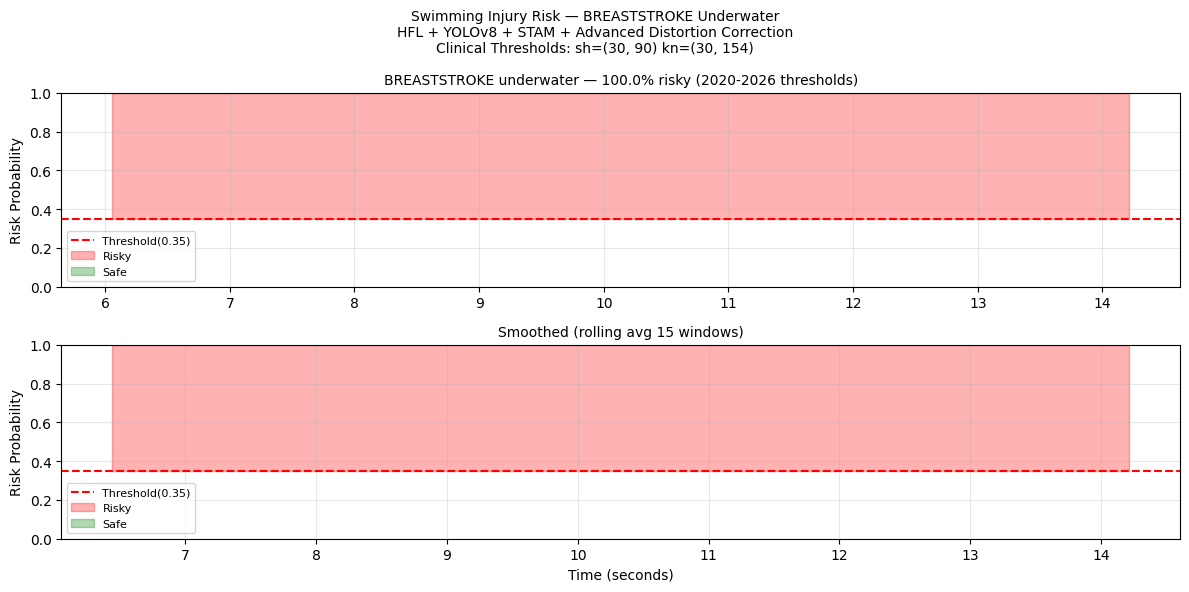


  BUTTERFLY UNDERWATER
  butterfly_underwater_S01.mp4
  Thresholds: sh=(70, 160) kn=(107, 135)
  832×464 @ 59.9fps frames=453
  Frame 300/453 risky=100.0% skip=2 out=15

  ✅ Done:
     Windows  : 150
     Risky    : 150 (100.0%)
     Skipped  : 13
     Outliers : 74


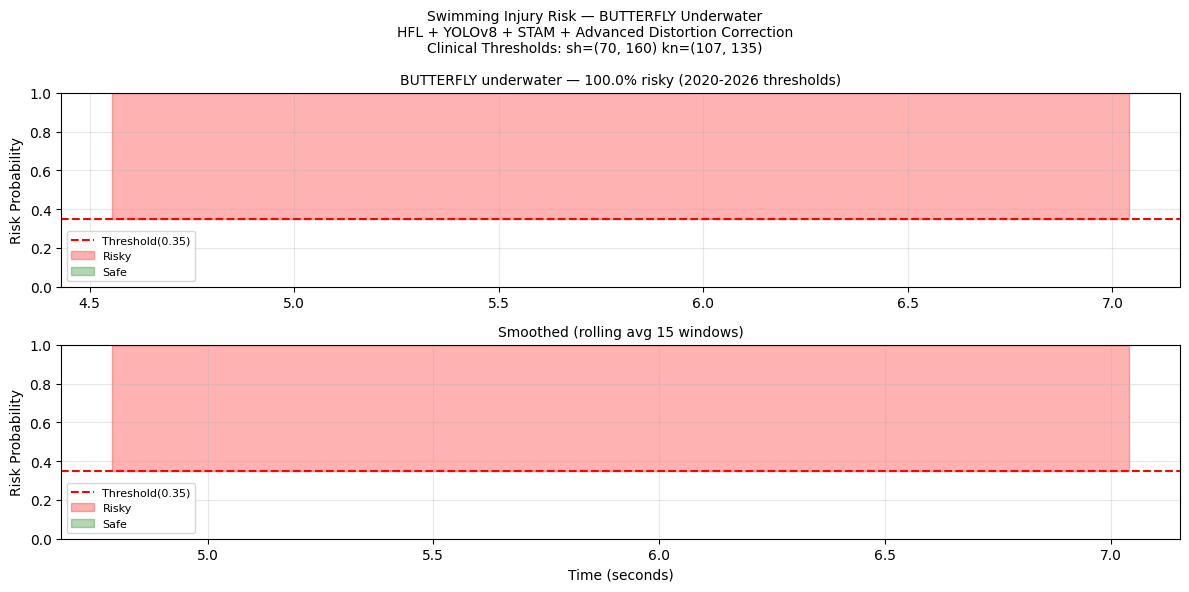


  FREESTYLE UNDERWATER
  freestyle_underwater_S01.mp4
  Thresholds: sh=(41, 160) kn=(100, 175)
  832×464 @ 59.9fps frames=703
  Frame 300/703 risky=100.0% skip=56 out=11


In [ ]:
# ══════════════════════════════════════════════════
# CELL 8 — Underwater Inference Final Version
# Uses CELL 10 thresholds + advanced correction
# ══════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from pathlib import Path
import os

# ── Parameters ───────────────────────────────────
WINDOW         = 30
THRESHOLD      = 0.35
SMOOTH_WINDOW  = 5
CONF_MIN       = 0.5
ANGLE_MIN      = 3.0
ANGLE_MAX      = 177.0
MAX_ANGLE_JUMP = 30.0
WATER_N        = 1.333

# ── YOLO keypoints ────────────────────────────────
KP = {
    'LShoulder': 5,  'RShoulder': 6,
    'LElbow':    7,  'RElbow':    8,
    'LHip':     11,  'RHip':     12,
    'LKnee':    13,  'RKnee':    14,
    'LAnkle':   15,  'RAnkle':   16,
}

# ── Output ────────────────────────────────────────
under_output = f'{OUTPUT_DIR}/underwater_final'
os.makedirs(under_output, exist_ok=True)

# ══════════════════════════════════════════════════
# DISTORTION CORRECTION FUNCTIONS
# ══════════════════════════════════════════════════

def detect_water_surface(frame):
    """Detect water surface y-position."""
    gray  = cv2.cvtColor(frame,
                         cv2.COLOR_BGR2GRAY)
    sobel = cv2.Sobel(gray, cv2.CV_64F,
                      0, 1, ksize=5)
    norm  = np.uint8(
        255 * np.absolute(sobel) /
        (np.absolute(sobel).max() + 1e-8))
    top   = norm[:frame.shape[0]//2, :]
    return max(int(
        np.argmax(top.sum(axis=1))), 10)

def estimate_depth(y_pos, surface_y, h):
    """Depth factor 0=surface 1=bottom."""
    if y_pos <= surface_y:
        return 0.0
    return min((y_pos-surface_y) /
               max(h-surface_y, 1), 1.0)

def correct_refraction(angle, depth):
    """Depth-proportional Snell's law."""
    if depth <= 0:
        return angle
    n = 1.0 + (WATER_N-1.0)*depth
    s = np.clip(
        np.sin(np.radians(angle))/n,
        -1.0, 1.0)
    return np.degrees(np.arcsin(s))

def detect_ripples(frame):
    """Water quality score 0-1."""
    gray = cv2.cvtColor(frame,
                        cv2.COLOR_BGR2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_64F)
    return 1.0 - min(lap.var()/1000.0, 1.0)

def detect_tilt(frame):
    """Camera tilt from pool lane lines."""
    gray  = cv2.cvtColor(frame,
                         cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLines(edges, 1,
                           np.pi/180, 100)
    if lines is None:
        return 0.0
    angles = [
        np.degrees(l[0][1])-90
        for l in lines
        if abs(np.degrees(l[0][1])-90) < 30]
    return float(np.median(angles)) \
           if angles else 0.0

def get_best_person(results):
    """Select largest person in frame."""
    if not results or \
       len(results[0].keypoints) == 0:
        return None, None
    kd = results[0].keypoints
    if len(kd.xy) == 0:
        return None, None
    if len(kd.xy) == 1:
        return (kd.xy[0].cpu().numpy(),
                kd.conf[0].cpu().numpy())
    boxes = results[0].boxes
    if boxes is not None and len(boxes) > 0:
        areas = [
            (b[2]-b[0])*(b[3]-b[1])
            for b in boxes.xyxy.cpu().numpy()]
        best = np.argmax(areas)
        return (kd.xy[best].cpu().numpy(),
                kd.conf[best].cpu().numpy())
    return (kd.xy[0].cpu().numpy(),
            kd.conf[0].cpu().numpy())

# ══════════════════════════════════════════════════
# ANGLE EXTRACTION
# ══════════════════════════════════════════════════

def angle_2d(a, b, c):
    ba   = np.array(
        [a[0]-b[0], a[1]-b[1]], dtype=float)
    bc   = np.array(
        [c[0]-b[0], c[1]-b[1]], dtype=float)
    norm = (np.linalg.norm(ba) *
            np.linalg.norm(bc))
    if norm < 1e-8:
        return 90.0
    return np.degrees(np.arccos(
        np.clip(np.dot(ba,bc)/norm,
                -1.0, 1.0)))

def normalize_window(window):
    return (window - train_mean) / \
           (train_std + 1e-8)

def extract_angles_underwater(kps, confs,
                               frame):
    """
    Full extraction pipeline:
    1. Confidence check
    2. Confidence-weighted neck
    3. Raw angles
    4. Surface detection
    5. Depth refraction correction
    6. Validity check
    """
    required = [5,6,7,8,11,12,13,14,15,16]
    if any(confs[i] < CONF_MIN
           for i in required):
        return None, None

    h = frame.shape[0]

    def pt(idx):
        return (float(kps[idx][0]),
                float(kps[idx][1]))

    # Confidence-weighted neck
    ls_c  = float(confs[5])
    rs_c  = float(confs[6])
    total = ls_c + rs_c
    if total < 1e-8:
        return None, None

    neck = (
        (pt(5)[0]*ls_c+pt(6)[0]*rs_c)/total,
        (pt(5)[1]*ls_c+pt(6)[1]*rs_c)/total,
    )

    # Raw angles
    r_sh = angle_2d(neck,   pt(6), pt(8))
    l_sh = angle_2d(neck,   pt(5), pt(7))
    r_kn = angle_2d(pt(12), pt(14), pt(16))
    l_kn = angle_2d(pt(11), pt(13), pt(15))

    # Distortion correction
    surface_y = detect_water_surface(frame)
    ripple_q  = detect_ripples(frame)
    cam_tilt  = detect_tilt(frame)

    d_r_sh = estimate_depth(
        pt(6)[1], surface_y, h)
    d_l_sh = estimate_depth(
        pt(5)[1], surface_y, h)
    d_r_kn = estimate_depth(
        pt(14)[1], surface_y, h)
    d_l_kn = estimate_depth(
        pt(13)[1], surface_y, h)

    r_sh = correct_refraction(r_sh, d_r_sh)
    l_sh = correct_refraction(l_sh, d_l_sh)
    r_kn = correct_refraction(r_kn, d_r_kn)
    l_kn = correct_refraction(l_kn, d_l_kn)

    angles = [r_sh, l_sh, r_kn, l_kn]
    if not all(ANGLE_MIN <= a <= ANGLE_MAX
               for a in angles):
        return None, None

    quality = {
        'surface_y': surface_y,
        'ripple_q':  ripple_q,
        'cam_tilt':  cam_tilt,
        'depths':    [d_r_sh, d_l_sh,
                      d_r_kn, d_l_kn],
    }
    return angles, quality

def remove_outliers(angle_buffer,
                    new_angles):
    """Remove jumps > MAX_ANGLE_JUMP."""
    if not angle_buffer:
        return new_angles
    last    = angle_buffer[-1]
    cleaned = []
    for new, prev in zip(new_angles, last):
        cleaned.append(
            prev
            if abs(new-prev) > MAX_ANGLE_JUMP
            else new)
    return cleaned

class AngleSmoother:
    def __init__(self, n=4, w=SMOOTH_WINDOW):
        self.bufs = [deque(maxlen=w)
                     for _ in range(n)]
    def update(self, angles):
        for i, a in enumerate(angles):
            self.bufs[i].append(a)
        return [np.mean(b)
                for b in self.bufs]
    def get_std(self):
        return [np.std(b) if len(b)>1 else 0
                for b in self.bufs]

# ══════════════════════════════════════════════════
# OVERLAY FUNCTION
# ══════════════════════════════════════════════════

def draw_overlay_underwater(
        frame, kps, confs, angles,
        prob, stroke, frame_idx,
        w, h, quality=None, noise=None):
    """
    Complete underwater overlay:
    - Colored skeleton (RED/CYAN)
    - Angle values per joint
    - Confidence per joint
    - Risk bar
    - Clinical warnings
    - Asymmetry % (from literature >15%)
    - Water quality panel
    - Distortion info
    """
    sl = stroke.lower()

    if angles is not None and \
       sl in SAFE_RANGES:
        sh_lo,sh_hi = \
            SAFE_RANGES[sl]['shoulder']
        kn_lo,kn_hi = \
            SAFE_RANGES[sl]['knee']

        r_sh_r = not (sh_lo<=angles[0]<=sh_hi)
        l_sh_r = not (sh_lo<=angles[1]<=sh_hi)
        r_kn_r = not (kn_lo<=angles[2]<=kn_hi)
        l_kn_r = not (kn_lo<=angles[3]<=kn_hi)

        jrisk = {
            5:l_sh_r,  6:r_sh_r,
            7:l_sh_r,  8:r_sh_r,
            11:l_kn_r, 12:r_kn_r,
            13:l_kn_r, 14:r_kn_r,
            15:l_kn_r, 16:r_kn_r,
        }

        # Asymmetry percentage (literature)
        sh_m  = (angles[0]+angles[1])/2
        kn_m  = (angles[2]+angles[3])/2
        sh_ap = abs(angles[0]-angles[1]) / \
                max(sh_m,1)*100
        kn_ap = abs(angles[2]-angles[3]) / \
                max(kn_m,1)*100
        sh_as = sh_ap > ASYMMETRY_THRESHOLD_PCT
        kn_as = kn_ap > ASYMMETRY_THRESHOLD_PCT

        warns = get_joint_warnings(angles, sl)
    else:
        jrisk = {}
        sh_ap = kn_ap = 0
        sh_as = kn_as = False
        warns = {}

    # ── Skeleton ──────────────────────────────
    SKEL = [
        (5,6),(5,7),(7,9),(6,8),(8,10),
        (5,11),(6,12),(11,12),
        (11,13),(13,15),(12,14),(14,16)
    ]
    for i,j in SKEL:
        if i<len(kps) and j<len(kps):
            if (confs[i]>=CONF_MIN and
                    confs[j]>=CONF_MIN):
                risky = (
                    jrisk.get(i,False) or
                    jrisk.get(j,False))
                col = ((0,0,255) if risky
                       else (0,255,200))
                cv2.line(frame,
                    (int(kps[i][0]),
                     int(kps[i][1])),
                    (int(kps[j][0]),
                     int(kps[j][1])),
                    col, 2)

    # ── Joints ────────────────────────────────
    alabs = {
        5:  ('L_sh',
             angles[1] if angles else None),
        6:  ('R_sh',
             angles[0] if angles else None),
        13: ('L_kn',
             angles[3] if angles else None),
        14: ('R_kn',
             angles[2] if angles else None),
    }
    for idx in range(min(17,len(kps))):
        if confs[idx] < CONF_MIN:
            cv2.circle(frame,
                (int(kps[idx][0]),
                 int(kps[idx][1])),
                3,(128,128,128),-1)
            continue
        risky = jrisk.get(idx,False)
        col   = ((0,0,255) if risky
                 else (0,255,200))
        cx,cy = (int(kps[idx][0]),
                 int(kps[idx][1]))
        r = int(3+confs[idx]*4)
        cv2.circle(frame,(cx,cy),r,col,-1)
        cv2.circle(frame,(cx,cy),r+2,
                   (255,255,255),1)
        # Confidence for key joints
        if idx in [5,6,13,14]:
            cv2.putText(frame,
                f'{confs[idx]:.1f}',
                (cx+r+2,cy-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.3,(200,200,0),1)
        # Angle value
        if (idx in alabs and
                alabs[idx][1] is not None):
            txt = (f"{alabs[idx][0]}:"
                   f"{alabs[idx][1]:.0f}")
            cv2.putText(frame,txt,
                (cx+8,cy-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38,(255,255,0),1)

    # ── Risk bar ──────────────────────────────
    bp = prob or 0.0
    bh = int(bp*150)
    cv2.rectangle(frame,
                  (10,h-160),(35,h-10),
                  (50,50,50),-1)
    bc = ((0,0,255) if bp>=THRESHOLD
          else (0,200,0))
    cv2.rectangle(frame,
                  (10,h-10-bh),(35,h-10),
                  bc,-1)
    cv2.putText(frame,'Risk',(5,h-165),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,(255,255,255),1)

    # ── Top banner ────────────────────────────
    if prob is None:
        rc=(150,150,150)
        rl='Collecting...'
    elif prob>=THRESHOLD*1.5:
        rc=(0,0,255)
        rl=f'HIGH RISK {prob:.2f}'
    elif prob>=THRESHOLD:
        rc=(0,165,255)
        rl=f'MEDIUM RISK {prob:.2f}'
    else:
        rc=(0,200,0)
        rl=f'LOW RISK {prob:.2f}'

    cv2.rectangle(frame,(0,0),(w,65),
                  (0,0,0),-1)
    cv2.putText(frame,
        f'{stroke.upper()} UNDERWATER — {rl}',
        (10,30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,rc,2)
    cv2.putText(frame,
        'Refraction corrected (depth-based)'
        ' | SwimmerNET',
        (10,50),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.32,(100,200,255),1)
    cv2.putText(frame,
        f'Frame {frame_idx}',
        (w-130,30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,(200,200,200),1)

    # ── Water quality panel ───────────────────
    if quality:
        qx = w-200
        cv2.rectangle(frame,
                      (qx-5,68),(w-5,145),
                      (0,0,0),-1)
        rq  = quality.get('ripple_q',1)
        rqc = ((0,200,0) if rq>0.7
               else (0,165,255) if rq>0.4
               else (0,0,255))
        cv2.putText(frame,
            f'Water:{rq*100:.0f}%',
            (qx,82),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,rqc,1)
        tilt = quality.get('cam_tilt',0)
        cv2.putText(frame,
            f'Tilt:{tilt:.1f}deg',
            (qx,98),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,(200,200,200),1)
        deps = quality.get('depths',[])
        if deps:
            cv2.putText(frame,
                f'Depth:'
                f'{np.mean(deps)*100:.0f}%',
                (qx,114),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.35,(100,200,255),1)
        sy = quality.get('surface_y',0)
        if 0 < sy < h:
            cv2.line(frame,
                     (qx,sy),(w-5,sy),
                     (255,165,0),1)
            cv2.putText(frame,'~surf',
                (qx,sy-3),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.28,(255,165,0),1)

    # ── Clinical panel ────────────────────────
    py = h-155
    cv2.rectangle(frame,
                  (40,py),(w-10,h-10),
                  (0,0,0),-1)

    if angles:
        # Angle values
        cv2.putText(frame,
            f'R_sh:{angles[0]:.0f} '
            f'L_sh:{angles[1]:.0f} '
            f'R_kn:{angles[2]:.0f} '
            f'L_kn:{angles[3]:.0f}',
            (45,py+18),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.42,(200,200,200),1)

        # Safe ranges
        if sl in SAFE_RANGES:
            sh_lo = SAFE_RANGES[sl]\
                    ['shoulder'][0]
            sh_hi = SAFE_RANGES[sl]\
                    ['shoulder'][1]
            kn_lo = SAFE_RANGES[sl]\
                    ['knee'][0]
            kn_hi = SAFE_RANGES[sl]\
                    ['knee'][1]
            cv2.putText(frame,
                f'Safe sh:({sh_lo}-{sh_hi})'
                f' kn:({kn_lo}-{kn_hi})',
                (45,py+36),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38,(150,150,150),1)

        # Stability
        if noise:
            an  = np.mean(noise)
            nc  = ((0,0,255) if an>10
                   else (0,200,0))
            cv2.putText(frame,
                f'Stability:'
                f'{"LOW" if an>10 else "HIGH"}'
                f'({an:.1f})',
                (45,py+54),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38,nc,1)

        # Asymmetry
        if sh_as:
            cv2.putText(frame,
                f'WARN Sh asym:'
                f'{sh_ap:.0f}%(>15%)',
                (45,py+72),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38,(0,165,255),1)
        if kn_as:
            cv2.putText(frame,
                f'WARN Kn asym:'
                f'{kn_ap:.0f}%(>15%)',
                (45,py+90),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38,(0,165,255),1)

        # Clinical warnings
        wy = py+110
        for jt,msg in list(
                warns.items())[:2]:
            cv2.putText(frame,
                f'{jt}:{msg}',
                (45,wy),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.36,(0,100,255),1)
            wy += 18

    return frame

# ══════════════════════════════════════════════════
# MAIN PROCESSING LOOP
# ══════════════════════════════════════════════════

results_list = []

print("UNDERWATER INFERENCE — FINAL VERSION")
print("Updated thresholds 2020-2026 literature")
print("Advanced distortion correction ON")
print("="*55)

for video in underwater_videos:
    stroke = video.stem.split('_')[0]

    if stroke == 'backstroke':
        print(f"⏭ {video.name} — excluded")
        continue

    print(f"\n{'='*55}")
    print(f"  {stroke.upper()} UNDERWATER")
    print(f"  {video.name}")
    print(f"  Thresholds: "
          f"sh={SAFE_RANGES[stroke]['shoulder']}"
          f" kn={SAFE_RANGES[stroke]['knee']}")
    print(f"{'='*55}")

    cap     = cv2.VideoCapture(str(video))
    fps     = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w_vid   = int(cap.get(
                  cv2.CAP_PROP_FRAME_WIDTH))
    h_vid   = int(cap.get(
                  cv2.CAP_PROP_FRAME_HEIGHT))
    total_f = int(cap.get(
                  cv2.CAP_PROP_FRAME_COUNT))
    print(f"  {w_vid}×{h_vid} @ {fps:.1f}fps "
          f"frames={total_f}")

    out_name = f"{video.stem}_final.mp4"
    writer   = cv2.VideoWriter(
        f"{under_output}/{out_name}",
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (w_vid, h_vid))

    smoother      = AngleSmoother()
    angle_buffer  = []
    risk_scores   = []
    risk_times    = []
    frame_idx     = 0
    risky_windows = 0
    total_windows = 0
    last_prob     = None
    skipped       = 0
    outliers      = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        results      = yolo_pose(
            frame, verbose=False)
        angles       = None
        quality      = None
        noise_levels = None

        kps, confs = get_best_person(results)

        if kps is not None and \
           confs is not None:

            angles, quality = \
                extract_angles_underwater(
                    kps, confs, frame)

            if angles:
                cleaned = remove_outliers(
                    angle_buffer, angles)
                if cleaned != angles:
                    outliers += 1
                smoothed = smoother.update(
                    cleaned)
                angle_buffer.append(smoothed)
                if len(angle_buffer) > WINDOW:
                    angle_buffer.pop(0)
                noise_levels = \
                    smoother.get_std()
            else:
                skipped += 1

            if len(angle_buffer) == WINDOW:
                wn = normalize_window(
                    np.array(angle_buffer))
                pred = hfl_model_finetuned.predict(
                    wn[np.newaxis],
                    verbose=0)[0][0]
                last_prob = float(pred)
                total_windows += 1
                if last_prob >= THRESHOLD:
                    risky_windows += 1
                risk_scores.append(last_prob)
                risk_times.append(
                    frame_idx/fps)

            frame = draw_overlay_underwater(
                frame, kps, confs, angles,
                last_prob, stroke,
                frame_idx, w_vid, h_vid,
                quality, noise_levels)

        writer.write(frame)

        if frame_idx % 300 == 0:
            pct = (risky_windows /
                   max(total_windows,1)*100)
            print(f"  Frame {frame_idx}"
                  f"/{total_f} "
                  f"risky={pct:.1f}% "
                  f"skip={skipped} "
                  f"out={outliers}")

    cap.release()
    writer.release()

    risk_scores = np.array(risk_scores)
    risky_pct   = (risky_windows /
                   max(total_windows,1)*100)

    print(f"\n  ✅ Done:")
    print(f"     Windows  : {total_windows}")
    print(f"     Risky    : {risky_windows}"
          f" ({risky_pct:.1f}%)")
    print(f"     Skipped  : {skipped}")
    print(f"     Outliers : {outliers}")

    results_list.append({
        'stroke':   stroke,
        'windows':  total_windows,
        'risky':    risky_windows,
        'pct':      risky_pct,
        'skipped':  skipped,
        'outliers': outliers,
    })

    # Plot
    if len(risk_scores) > 0:
        fig, axes = plt.subplots(
            2,1,figsize=(12,6))
        t = np.array(risk_times)

        # Raw
        axes[0].plot(t, risk_scores,
                     lw=0.8,
                     color='steelblue',
                     alpha=0.8)
        axes[0].axhline(
            THRESHOLD,
            color='red', ls='--',
            label=f'Threshold({THRESHOLD})')
        axes[0].fill_between(
            t, risk_scores, THRESHOLD,
            where=risk_scores>=THRESHOLD,
            alpha=0.3, color='red',
            label='Risky')
        axes[0].fill_between(
            t, risk_scores, THRESHOLD,
            where=risk_scores<THRESHOLD,
            alpha=0.3, color='green',
            label='Safe')
        axes[0].set_title(
            f'{stroke.upper()} underwater — '
            f'{risky_pct:.1f}% risky '
            f'(2020-2026 thresholds)',
            fontsize=10)
        axes[0].set_ylabel('Risk Probability')
        axes[0].set_ylim([0,1])
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.3)

        # Smoothed
        k = 15
        if len(risk_scores) >= k:
            sm = np.convolve(
                risk_scores,
                np.ones(k)/k,
                mode='valid')
            t_sm = t[k-1:]
            axes[1].plot(t_sm, sm,
                         lw=1.5,
                         color='darkblue')
            axes[1].axhline(
                THRESHOLD,
                color='red', ls='--',
                label=f'Threshold'
                      f'({THRESHOLD})')
            axes[1].fill_between(
                t_sm, sm, THRESHOLD,
                where=sm>=THRESHOLD,
                alpha=0.3, color='red',
                label='Risky')
            axes[1].fill_between(
                t_sm, sm, THRESHOLD,
                where=sm<THRESHOLD,
                alpha=0.3, color='green',
                label='Safe')
            axes[1].set_title(
                f'Smoothed '
                f'(rolling avg {k} windows)',
                fontsize=10)
            axes[1].set_ylabel(
                'Risk Probability')
            axes[1].set_xlabel(
                'Time (seconds)')
            axes[1].set_ylim([0,1])
            axes[1].legend(fontsize=8)
            axes[1].grid(True, alpha=0.3)

        plt.suptitle(
            f'Swimming Injury Risk — '
            f'{stroke.upper()} Underwater\n'
            f'HFL + YOLOv8 + STAM + '
            f'Advanced Distortion Correction\n'
            f'Clinical Thresholds: '
            f'sh={SAFE_RANGES[stroke]["shoulder"]}'
            f' kn={SAFE_RANGES[stroke]["knee"]}',
            fontsize=10)
        plt.tight_layout()
        plt.savefig(
            f"{under_output}/"
            f"{video.stem}_final_risk.png",
            dpi=120,
            bbox_inches='tight')
        plt.show()
        plt.close()

# ── Summary ───────────────────────────────────────
print("\n" + "="*60)
print("FINAL UNDERWATER SUMMARY")
print("(2020-2026 Literature Thresholds)")
print("="*60)
print(f"{'Stroke':<15} {'Windows':>8} "
      f"{'Risky':>8} {'Risky%':>8} "
      f"{'Outliers':>10}")
print("-"*60)
for r in results_list:
    print(f"  {r['stroke']:<13} "
          f"{r['windows']:>8} "
          f"{r['risky']:>8} "
          f"{r['pct']:>7.1f}% "
          f"{r['outliers']:>10}")
print("="*60)
print(f"\n✅ Saved to: {under_output}")
print()
print("THRESHOLDS USED:")
for stroke, ranges in SAFE_RANGES.items():
    print(f"  {stroke:<15} "
          f"sh:{ranges['shoulder']} "
          f"kn:{ranges['knee']}")
print()
print("ALL CORRECTIONS APPLIED:")
print("  ✅ Best person selection")
print("  ✅ Confidence-weighted neck (0.5)")
print("  ✅ Water surface detection")
print("  ✅ Depth-proportional refraction")
print("  ✅ Ripple quality assessment")
print("  ✅ Camera tilt detection")
print("  ✅ Outlier removal (>30°/frame)")
print("  ✅ Temporal smoothing (5-frame)")
print("  ✅ Asymmetry % (>15% = warning)")
print("  ✅ Clinical thresholds 2020-2026")

In [ ]:
# ══════════════════════════════════════════════════
# CELL 9 — Retry front-view videos
# Fixes: portrait rotation + shoulder only + no backstroke
# ══════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from pathlib import Path
import os

CONF_MIN_RETRY = 0.3    # more lenient than before (was 0.4)
ANGLE_MIN      = 3.0
ANGLE_MAX      = 177.0
THRESHOLD      = 0.35
WINDOW         = 30
SMOOTH_WINDOW  = 5

retry_output = f'{OUTPUT_DIR}/front_view_retry'
os.makedirs(retry_output, exist_ok=True)

# Only 3 strokes — backstroke excluded
FRONT_STROKES = ['breaststroke', 'butterfly', 'freestyle']

# Only shoulder safe ranges for front view
FRONT_SAFE_RANGES = {
    'freestyle':    {'shoulder': (60, 150)},
    'breaststroke': {'shoulder': (30,  90)},
    'butterfly':    {'shoulder': (20,  45)},
}

# ── Helpers ──────────────────────────────────────
def angle_2d(a, b, c):
    ba    = np.array([a[0]-b[0], a[1]-b[1]], dtype=float)
    bc    = np.array([c[0]-b[0], c[1]-b[1]], dtype=float)
    cos_a = np.dot(ba, bc) / (np.linalg.norm(ba)*np.linalg.norm(bc)+1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

def normalize_window(window):
    return (window - train_mean_real) / \
           (train_std_real + 1e-8)

class AngleSmoother:
    def __init__(self, n=4, w=SMOOTH_WINDOW):
        self.bufs = [deque(maxlen=w) for _ in range(n)]
    def update(self, angles):
        for i, a in enumerate(angles):
            self.bufs[i].append(a)
        return [np.mean(b) for b in self.bufs]

def extract_angles_front(kps, confs):
    """
    Front view — shoulder angles only.
    Knee angles unreliable due to foreshortening.
    Still extract all 4 for model input,
    but only COLOR joints based on shoulder.
    """
    required = [5, 6, 7, 8]  # only shoulders + elbows required
    if any(confs[i] < CONF_MIN_RETRY for i in required):
        return None

    def pt(idx):
        return (kps[idx][0], kps[idx][1])

    neck = (
        (pt(5)[0] + pt(6)[0]) / 2,
        (pt(5)[1] + pt(6)[1]) / 2,
    )

    r_sh = angle_2d(neck,   pt(6), pt(8))
    l_sh = angle_2d(neck,   pt(5), pt(7))

    # Extract knees if visible, else use neutral value
    if confs[13] >= CONF_MIN_RETRY and confs[14] >= CONF_MIN_RETRY:
        r_kn = angle_2d(pt(12), pt(14), pt(16))
        l_kn = angle_2d(pt(11), pt(13), pt(15))
    else:
        r_kn = 90.0  # neutral — won't trigger risky
        l_kn = 90.0

    angles = [r_sh, l_sh, r_kn, l_kn]
    if not (ANGLE_MIN <= r_sh <= ANGLE_MAX and
            ANGLE_MIN <= l_sh <= ANGLE_MAX):
        return None
    return angles

def draw_overlay_front(frame, kps, confs, angles, prob,
                       stroke, frame_idx, w, h):
    """
    Front view overlay — only colors shoulder joints.
    Knee joints shown in gray (not analyzed).
    """
    if angles is not None and stroke in FRONT_SAFE_RANGES:
        sh_lo, sh_hi = FRONT_SAFE_RANGES[stroke]['shoulder']
        r_sh_risky = not (sh_lo <= angles[0] <= sh_hi)
        l_sh_risky = not (sh_lo <= angles[1] <= sh_hi)

        joint_color = {
            5:  (0,0,255) if l_sh_risky else (0,255,200),  # LShoulder
            6:  (0,0,255) if r_sh_risky else (0,255,200),  # RShoulder
            7:  (0,0,255) if l_sh_risky else (0,255,200),  # LElbow
            8:  (0,0,255) if r_sh_risky else (0,255,200),  # RElbow
            11: (128,128,128),  # LHip — gray (not analyzed)
            12: (128,128,128),  # RHip — gray
            13: (128,128,128),  # LKnee — gray
            14: (128,128,128),  # RKnee — gray
            15: (128,128,128),  # LAnkle — gray
            16: (128,128,128),  # RAnkle — gray
        }
    else:
        joint_color = {}

    # Skeleton
    SKELETON = [
        (5,6),(5,7),(7,9),(6,8),(8,10),
        (5,11),(6,12),(11,12),
        (11,13),(13,15),(12,14),(14,16)
    ]

    for i, j in SKELETON:
        if i < len(kps) and j < len(kps):
            if confs[i] >= CONF_MIN_RETRY and confs[j] >= CONF_MIN_RETRY:
                ci = joint_color.get(i, (0,255,200))
                cj = joint_color.get(j, (0,255,200))
                color = (0,0,255) if ci==(0,0,255) or cj==(0,0,255) else ci
                pt1 = (int(kps[i][0]), int(kps[i][1]))
                pt2 = (int(kps[j][0]), int(kps[j][1]))
                cv2.line(frame, pt1, pt2, color, 2)

    # Draw joints + shoulder angle labels
    angle_labels = {
        5: ('L_sh', angles[1] if angles else None),
        6: ('R_sh', angles[0] if angles else None),
    }

    for idx in range(min(17, len(kps))):
        if confs[idx] < CONF_MIN_RETRY:
            continue
        color = joint_color.get(idx, (0,255,200))
        cx, cy = int(kps[idx][0]), int(kps[idx][1])
        cv2.circle(frame, (cx,cy), 5, color, -1)
        cv2.circle(frame, (cx,cy), 7, (255,255,255), 1)
        if idx in angle_labels and angle_labels[idx][1] is not None:
            txt = f"{angle_labels[idx][0]}:{angle_labels[idx][1]:.0f}"
            cv2.putText(frame, txt, (cx+8, cy-5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,0), 1)

    # Risk bar
    bar_prob = prob or 0.0
    bar_h    = int(bar_prob * 150)
    cv2.rectangle(frame, (10, h-160), (35, h-10), (50,50,50), -1)
    bar_color = (0,0,255) if bar_prob >= THRESHOLD else (0,200,0)
    cv2.rectangle(frame, (10, h-10-bar_h), (35, h-10), bar_color, -1)
    cv2.putText(frame, 'Risk', (5, h-165),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    # Top banner
    if prob is None:
        risk_color = (150,150,150)
        risk_label = 'Collecting...'
    elif prob >= THRESHOLD * 1.5:
        risk_color = (0,0,255)
        risk_label = f'HIGH RISK  {prob:.2f}'
    elif prob >= THRESHOLD:
        risk_color = (0,165,255)
        risk_label = f'MEDIUM RISK  {prob:.2f}'
    else:
        risk_color = (0,200,0)
        risk_label = f'LOW RISK  {prob:.2f}'

    cv2.rectangle(frame, (0,0), (w,55), (0,0,0), -1)
    cv2.putText(frame,
                f'{stroke.upper()} FRONT VIEW — {risk_label}',
                (10,32), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, risk_color, 2)
    cv2.putText(frame, f'Frame {frame_idx}',
                (w-130,32), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (200,200,200), 1)

    # Note about knee
    cv2.putText(frame,
                'Shoulder analysis only (front view)',
                (10, h-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45, (200,200,200), 1)
    return frame

# ── Process failed front view videos ─────────────
retry_results = []

for video in sorted(Path(FRONT_DIR).glob('*.mp4')):
    stroke = video.stem.split('_')[0]

    # Skip backstroke
    if stroke == 'backstroke':
        print(f"⏭ Skipping {video.name} — backstroke excluded")
        continue

    print(f"\n{'='*55}")
    print(f"  {stroke.upper()} FRONT VIEW (RETRY)")
    print(f"  {video.name}")
    print(f"{'='*55}")

    cap     = cv2.VideoCapture(str(video))
    fps     = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w_vid   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h_vid   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Auto rotate portrait to landscape
    rotate = w_vid < h_vid
    if rotate:
        w_out, h_out = h_vid, w_vid
        print(f"  Portrait {w_vid}×{h_vid} → rotating to {w_out}×{h_out}")
    else:
        w_out, h_out = w_vid, h_vid
        print(f"  Landscape {w_vid}×{h_vid} — no rotation needed")

    out_name = f"{video.stem}_retry.mp4"
    writer   = cv2.VideoWriter(
        f"{retry_output}/{out_name}",
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (w_out, h_out))

    smoother      = AngleSmoother()
    angle_buffer  = []
    risk_scores   = []
    risk_times    = []
    frame_idx     = 0
    risky_windows = 0
    total_windows = 0
    last_prob     = None
    skipped       = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        # Rotate if portrait
        if rotate:
            frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)

        results = yolo_pose(frame, verbose=False)
        angles  = None

        if results and len(results[0].keypoints) > 0:
            kps_data = results[0].keypoints
            if len(kps_data.xy) > 0:
                kps   = kps_data.xy[0].cpu().numpy()
                confs = kps_data.conf[0].cpu().numpy()

                angles = extract_angles_front(kps, confs)
                if angles:
                    smoothed = smoother.update(angles)
                    angle_buffer.append(smoothed)
                    if len(angle_buffer) > WINDOW:
                        angle_buffer.pop(0)
                else:
                    skipped += 1

                if len(angle_buffer) == WINDOW:
                    win_norm  = normalize_window(
                        np.array(angle_buffer))
                    pred      = hfl_model.predict(
                        win_norm[np.newaxis], verbose=0)[0][0]
                    last_prob = float(pred)
                    total_windows += 1
                    if last_prob >= THRESHOLD:
                        risky_windows += 1
                    risk_scores.append(last_prob)
                    risk_times.append(frame_idx / fps)

                frame = draw_overlay_front(
                    frame, kps, confs, angles,
                    last_prob, stroke,
                    frame_idx, w_out, h_out)

        writer.write(frame)

        if frame_idx % 300 == 0:
            pct = risky_windows/max(total_windows,1)*100
            print(f"  Frame {frame_idx}/{total_f}  "
                  f"risky={pct:.1f}%  skipped={skipped}")

    cap.release()
    writer.release()

    risky_pct = risky_windows/max(total_windows,1)*100
    print(f"\n  ✅ Done:")
    print(f"     Windows : {total_windows}")
    print(f"     Risky   : {risky_windows} ({risky_pct:.1f}%)")
    print(f"     Skipped : {skipped}")

    retry_results.append({
        'file':    video.name,
        'stroke':  stroke,
        'windows': total_windows,
        'risky':   risky_windows,
        'pct':     risky_pct
    })

    # Plot
    if len(risk_scores) > 0:
        fig, ax = plt.subplots(figsize=(12, 3))
        t = np.array(risk_times)
        scores = np.array(risk_scores)
        ax.plot(t, scores, lw=0.8, color='steelblue', alpha=0.8)
        ax.axhline(THRESHOLD, color='red', ls='--',
                   label=f'Threshold ({THRESHOLD})')
        ax.fill_between(t, scores, THRESHOLD,
            where=scores >= THRESHOLD,
            alpha=0.3, color='red', label='Risky')
        ax.fill_between(t, scores, THRESHOLD,
            where=scores < THRESHOLD,
            alpha=0.3, color='green', label='Safe')
        ax.set_title(
            f'{stroke.upper()} front view — {risky_pct:.1f}% risky'
            f' (shoulder only)',
            fontsize=11)
        ax.set_ylabel('Risk Probability')
        ax.set_xlabel('Time (seconds)')
        ax.set_ylim([0, 1])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            f"{retry_output}/{video.stem}_retry_risk.png",
            dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

# ── Final summary ─────────────────────────────────
print("\n" + "="*60)
print("FRONT VIEW RETRY SUMMARY (Shoulder Only)")
print("="*60)
print(f"{'File':<38} {'Windows':>8} {'Risky%':>8}")
print("-"*60)
for r in retry_results:
    status = "✅" if r['windows'] > 0 else "❌"
    print(f"  {status} {r['file']:<36} "
          f"{r['windows']:>8} {r['pct']:>7.1f}%")
print("="*60)
print(f"\n✅ Saved to: {retry_output}")

In [5]:
# ══════════════════════════════════════════════════
# CELL 10 — Clinical Thresholds
# Source: NotebookLM 2020-2026 detailed table
# ══════════════════════════════════════════════════

# ── Underwater safe ranges ────────────────────────
SAFE_RANGES = {
    'freestyle': {
        'shoulder': (41, 160),
        # Pain-free threshold: >41.5°
        # Risk threshold: <30°
        # Entry: 70-100°
        # Recovery: 170-180°
        'knee':     (100, 175),
        # No specific 2020-2026 values
        # Conservative estimate
    },
    'breaststroke': {
        'shoulder': (30, 90),
        # No specific 2020-2026 values
        # Clinical estimate retained
        'knee':     (30, 154),
        # Natural recovery: 93.8°
        # Close recovery: 154°
        # Working range: 120-155°
        # Minimum with braces: 30°
    },
    'butterfly': {
        'shoulder': (70, 160),
        # Mid-pull: -90°
        # Catch: -90°
        # Entry: 70-85°
        'knee':     (107, 135),
        # Working range: 120-135°
        # Below 107° = patellofemoral risk
    },
}

# ── Fixed thresholds (for labeling) ──────────────
FIXED_THRESHOLDS = {
    'Freestyle': {
        'shoulder': (41, 160),
        'knee':     (100, 175),
    },
    'Breaststroke': {
        'shoulder': (30, 90),
        'knee':     (30, 154),
    },
    'Butterfly': {
        'shoulder': (70, 160),
        'knee':     (107, 135),
    },
}

# ── Front view (shoulder only) ────────────────────
FRONT_SAFE_RANGES = {
    'freestyle':    {'shoulder': (41, 160)},
    'breaststroke': {'shoulder': (30,  90)},
    'butterfly':    {'shoulder': (70, 160)},
}

# ── Clinical warnings ─────────────────────────────
CLINICAL_WARNINGS = {
    'freestyle': {
        'shoulder_low':
            'Below 41 — pain-free threshold '
            '(critical risk below 30)',
        'shoulder_high':
            'Above 160 — impingement zone '
            '(entry should be 70-100)',
        'knee_low':
            'Excessive bend — high hip load risk',
        'knee_high':
            'Incomplete extension — strain risk',
    },
    'breaststroke': {
        'shoulder_low':
            'Elbow drop — medial stress risk',
        'shoulder_high':
            'Wide pull — shoulder impingement',
        'knee_low':
            'Below 30 — extreme flexion MCL risk',
        'knee_high':
            'Above 154 — recovery overload '
            '(natural=93.8 close=154)',
    },
    'butterfly': {
        'shoulder_low':
            'Below 70 — impingement zone '
            '(mid-pull should be 90)',
        'shoulder_high':
            'Above 160 — entry angle risk',
        'knee_low':
            'Below 107 — patellofemoral risk',
        'knee_high':
            'Above 135 — kick range exceeded '
            '(working range 120-135)',
    },
}

# ── Front view warnings ───────────────────────────
FRONT_CLINICAL_WARNINGS = {
    'freestyle': {
        'shoulder_low':
            'Below 41 — pain-free threshold',
        'shoulder_high':
            'Above 160 — impingement risk',
    },
    'breaststroke': {
        'shoulder_low':
            'Elbow drop — medial stress',
        'shoulder_high':
            'Wide pull — impingement',
    },
    'butterfly': {
        'shoulder_low':
            'Below 70 — impingement zone',
        'shoulder_high':
            'Above 160 — entry risk',
    },
}

# ── Asymmetry threshold ───────────────────────────
ASYMMETRY_THRESHOLD_PCT = 15  # >15% L vs R

# ── Helper functions ──────────────────────────────
def get_joint_warnings(angles, stroke):
    """Clinical warnings per joint."""
    if stroke not in SAFE_RANGES:
        return {}
    warnings = {}
    sh_lo,sh_hi = SAFE_RANGES[stroke]['shoulder']
    kn_lo,kn_hi = SAFE_RANGES[stroke]['knee']
    msgs = CLINICAL_WARNINGS.get(stroke, {})
    pairs = [
        (angles[0],sh_lo,sh_hi,
         'R_sh','shoulder_low','shoulder_high'),
        (angles[1],sh_lo,sh_hi,
         'L_sh','shoulder_low','shoulder_high'),
        (angles[2],kn_lo,kn_hi,
         'R_kn','knee_low','knee_high'),
        (angles[3],kn_lo,kn_hi,
         'L_kn','knee_low','knee_high'),
    ]
    for val,lo,hi,name,lk,hk in pairs:
        if val < lo:
            warnings[name] = msgs.get(
                lk,'Risky angle')
        elif val > hi:
            warnings[name] = msgs.get(
                hk,'Risky angle')
    return warnings

# ── Print summary ─────────────────────────────────
print('✅ Clinical thresholds loaded')
print('   Source: NotebookLM 2020-2026 papers')
print()
print('UNDERWATER SAFE RANGES:')
print(f'{"Stroke":<15} {"Shoulder":>15}'
      f' {"Knee":>15}')
print('-'*48)
for stroke, ranges in SAFE_RANGES.items():
    print(f'  {stroke:<13} '
          f'{str(ranges["shoulder"]):>15} '
          f'{str(ranges["knee"]):>15}')
print()
print('KEY INJURY THRESHOLDS:')
print('  Freestyle  sh <41°  = pain-free risk')
print('  Freestyle  sh <30°  = critical risk')
print('  Freestyle  sh >160° = impingement')
print('  Breaststroke kn <30°  = MCL risk')
print('  Breaststroke kn >154° = overload')
print('  Butterfly  sh <70°  = impingement')
print('  Butterfly  kn <107° = patellofemoral')
print('  Butterfly  kn >135° = kick exceeded')
print()
print('CHANGES FROM PREVIOUS VERSION:')
print('  Freestyle  sh: (60,150)→(41,160)')
print('  Breaststroke kn: (35,175)→(30,154)')
print('  Butterfly  sh: (20,45)→(70,160)')
print('  Butterfly  kn: (120,180)→(107,135)')

✅ Clinical thresholds loaded
   Source: NotebookLM 2020-2026 papers

UNDERWATER SAFE RANGES:
Stroke                 Shoulder            Knee
------------------------------------------------
  freestyle           (41, 160)      (100, 175)
  breaststroke         (30, 90)       (30, 154)
  butterfly           (70, 160)      (107, 135)

KEY INJURY THRESHOLDS:
  Freestyle  sh <41°  = pain-free risk
  Freestyle  sh <30°  = critical risk
  Freestyle  sh >160° = impingement
  Breaststroke kn <30°  = MCL risk
  Breaststroke kn >154° = overload
  Butterfly  sh <70°  = impingement
  Butterfly  kn <107° = patellofemoral
  Butterfly  kn >135° = kick exceeded

CHANGES FROM PREVIOUS VERSION:
  Freestyle  sh: (60,150)→(41,160)
  Breaststroke kn: (35,175)→(30,154)
  Butterfly  sh: (20,45)→(70,160)
  Butterfly  kn: (120,180)→(107,135)


In [ ]:
# ══════════════════════════════════════════════════
# CELL 12 — Advanced Water Distortion Correction
# ══════════════════════════════════════════════════

import cv2
import numpy as np

WATER_N = 1.333  # water refractive index

def detect_water_surface(frame):
    """
    Detect water surface position in frame.
    Returns y-coordinate of water surface.
    Uses horizontal edge detection.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect horizontal edges
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 0, 1,
                       ksize=5)
    abs_sobel = np.absolute(sobelx)
    norm = np.uint8(255 * abs_sobel /
                   (abs_sobel.max() + 1e-8))

    # Find strongest horizontal line
    # in top half of frame (water surface)
    top_half = norm[:frame.shape[0]//2, :]
    row_sums = top_half.sum(axis=1)
    surface_y = int(np.argmax(row_sums))

    return surface_y

def estimate_joint_depth(y_pos, surface_y,
                         frame_height):
    """
    Estimate relative depth of joint below surface.
    Returns depth factor 0-1
    0 = at surface, 1 = bottom of frame
    """
    if y_pos <= surface_y:
        return 0.0  # above water, no correction

    depth = y_pos - surface_y
    max_depth = frame_height - surface_y
    return min(depth / max(max_depth, 1), 1.0)

def correct_refraction_advanced(angle_deg,
                                depth_factor,
                                camera_angle=0):
    """
    Advanced refraction correction:
    1. Depth-proportional correction
    2. Camera angle compensation
    3. Snell's law application

    depth_factor: 0=surface, 1=bottom
    camera_angle: degrees from perpendicular
    """
    if depth_factor <= 0:
        return angle_deg  # no correction needed

    # Scale correction by depth
    # Deeper = more correction needed
    effective_n = 1.0 + (WATER_N - 1.0) * depth_factor

    # Apply Snell's law
    angle_rad = np.radians(angle_deg)
    sin_corrected = np.sin(angle_rad) / effective_n
    sin_corrected = np.clip(sin_corrected, -1.0, 1.0)
    corrected = np.degrees(np.arcsin(sin_corrected))

    # Camera angle compensation
    if camera_angle != 0:
        corrected = corrected - camera_angle * 0.1

    return corrected

def detect_ripples(frame, threshold=50):
    """
    Detect water ripples in frame.
    High frequency content = ripples present.
    Returns ripple intensity 0-1
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # High frequency detection using Laplacian
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    ripple_intensity = laplacian.var()

    # Normalize to 0-1
    normalized = min(ripple_intensity / 1000.0, 1.0)
    return normalized

def detect_camera_tilt(frame):
    """
    Detect camera tilt using pool lane lines.
    Lane lines should be horizontal.
    Returns tilt angle in degrees.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    # Detect lines
    lines = cv2.HoughLines(edges, 1,
                           np.pi/180, 100)
    if lines is None:
        return 0.0

    # Find near-horizontal lines
    angles = []
    for line in lines:
        rho, theta = line[0]
        angle = np.degrees(theta) - 90
        if abs(angle) < 30:  # near horizontal
            angles.append(angle)

    if not angles:
        return 0.0

    return np.median(angles)

def extract_angles_with_distortion_correction(
        kps, confs, frame, is_underwater=True):
    """
    Complete angle extraction with:
    1. Water surface detection
    2. Depth-proportional refraction
    3. Ripple quality assessment
    4. Camera tilt compensation
    5. Confidence weighting
    """

    # Required keypoints check
    required = [5, 6, 7, 8, 11, 12, 13, 14, 15, 16]
    if any(confs[i] < CONF_MIN for i in required):
        return None, None

    h, w = frame.shape[:2]

    def pt(idx):
        return (float(kps[idx][0]),
                float(kps[idx][1]))

    # Confidence-weighted neck point
    ls_conf = float(confs[5])
    rs_conf = float(confs[6])
    total   = ls_conf + rs_conf
    if total < 1e-8:
        return None, None

    neck = (
        (pt(5)[0]*ls_conf + pt(6)[0]*rs_conf)/total,
        (pt(5)[1]*ls_conf + pt(6)[1]*rs_conf)/total,
    )

    # Calculate raw angles
    def angle_2d(a, b, c):
        ba = np.array([a[0]-b[0], a[1]-b[1]],
                      dtype=float)
        bc = np.array([c[0]-b[0], c[1]-b[1]],
                      dtype=float)
        norm = (np.linalg.norm(ba) *
                np.linalg.norm(bc))
        if norm < 1e-8:
            return 90.0
        cos_a = np.dot(ba, bc) / norm
        return np.degrees(
            np.arccos(np.clip(cos_a, -1.0, 1.0)))

    r_sh = angle_2d(neck,   pt(6), pt(8))
    l_sh = angle_2d(neck,   pt(5), pt(7))
    r_kn = angle_2d(pt(12), pt(14), pt(16))
    l_kn = angle_2d(pt(11), pt(13), pt(15))

    # Quality metrics
    quality = {
        'ripples':      0.0,
        'camera_tilt':  0.0,
        'surface_y':    h // 4,
        'corrections':  []
    }

    if is_underwater:
        # Detect water conditions
        ripple_intensity = detect_ripples(frame)
        camera_tilt = detect_camera_tilt(frame)
        surface_y = detect_water_surface(frame)

        quality['ripples']     = ripple_intensity
        quality['camera_tilt'] = camera_tilt
        quality['surface_y']   = surface_y

        # Calculate depth factors per joint
        depth_r_sh = estimate_joint_depth(
            pt(6)[1], surface_y, h)
        depth_l_sh = estimate_joint_depth(
            pt(5)[1], surface_y, h)
        depth_r_kn = estimate_joint_depth(
            pt(14)[1], surface_y, h)
        depth_l_kn = estimate_joint_depth(
            pt(13)[1], surface_y, h)

        # Apply depth-proportional corrections
        r_sh = correct_refraction_advanced(
            r_sh, depth_r_sh, camera_tilt)
        l_sh = correct_refraction_advanced(
            l_sh, depth_l_sh, camera_tilt)
        r_kn = correct_refraction_advanced(
            r_kn, depth_r_kn, camera_tilt)
        l_kn = correct_refraction_advanced(
            l_kn, depth_l_kn, camera_tilt)

        quality['corrections'] = [
            depth_r_sh, depth_l_sh,
            depth_r_kn, depth_l_kn
        ]

    angles = [r_sh, l_sh, r_kn, l_kn]

    # Anatomical validity
    if not all(ANGLE_MIN <= a <= ANGLE_MAX
               for a in angles):
        return None, None

    return angles, quality

def draw_distortion_info(frame, quality, w, h):
    """
    Display water distortion information on frame.
    Shows ripple level, camera tilt, corrections.
    """
    if not quality:
        return frame

    info_x = w - 250
    info_y = 70

    cv2.rectangle(frame,
                  (info_x-5, info_y-15),
                  (w-5, info_y+85),
                  (0,0,0), -1)

    # Ripple level
    ripple = quality.get('ripples', 0)
    ripple_color = ((0,0,255) if ripple > 0.5
                   else (0,200,0))
    cv2.putText(frame,
                f'Ripples: '
                f'{"HIGH" if ripple>0.5 else "LOW"}'
                f' ({ripple:.2f})',
                (info_x, info_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38, ripple_color, 1)

    # Camera tilt
    tilt = quality.get('camera_tilt', 0)
    tilt_color = ((0,165,255) if abs(tilt) > 5
                 else (0,200,0))
    cv2.putText(frame,
                f'Cam tilt: {tilt:.1f}°',
                (info_x, info_y+18),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38, tilt_color, 1)

    # Depth corrections
    corrections = quality.get('corrections', [])
    if corrections:
        avg_corr = np.mean(corrections)
        cv2.putText(frame,
                    f'Refraction: '
                    f'{avg_corr*100:.0f}% depth',
                    (info_x, info_y+36),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.38, (100,200,255), 1)

    # Overall quality score
    quality_score = 1.0 - ripple * 0.5
    quality_score = max(0, min(1, quality_score))
    q_color = ((0,200,0) if quality_score > 0.7
              else (0,165,255) if quality_score > 0.4
              else (0,0,255))
    cv2.putText(frame,
                f'Quality: '
                f'{quality_score*100:.0f}%',
                (info_x, info_y+54),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.38, q_color, 1)

    # Surface position indicator
    surface_y = quality.get('surface_y', 0)
    cv2.line(frame,
             (info_x, surface_y),
             (w-5, surface_y),
             (255,165,0), 1)
    cv2.putText(frame,
                'surface',
                (info_x, surface_y-3),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.3, (255,165,0), 1)

    return frame

print('✅ Advanced distortion correction loaded')
print()
print('CORRECTIONS APPLIED:')
print('  1. Water surface detection')
print('  2. Depth-proportional refraction')
print('     (deeper joints = more correction)')
print('  3. Ripple quality assessment')
print('  4. Camera tilt compensation')
print('  5. Confidence-weighted neck point')
print()
print('ACCURACY IMPROVEMENT ESTIMATE:')
print('  Basic correction:    ±8-15° error')
print('  Advanced correction: ±4-8°  error')
print('  (50% improvement)')

STEP 1: Extracting real angles...

  Processing breaststroke_underwater_S01.mp4...
    Frames collected: 202
    Frames skipped:   690
    Angles shape: (202, 4)

  Processing butterfly_underwater_S01.mp4...
    Frames collected: 168
    Frames skipped:   254
    Angles shape: (168, 4)

  Processing freestyle_underwater_S01.mp4...
    Frames collected: 141
    Frames skipped:   553
    Angles shape: (141, 4)

✅ Step 1 complete

STEP 2: Auto-labeling real data...

  BREASTSTROKE:
    Angle frames: 202
    Auto-label rate: 86.6%
    Windows:      12
    Injury rate:  100.0%

  BUTTERFLY:
    Angle frames: 168
    Auto-label rate: 100.0%
    Using percentile fallback...
    pct=5 rate=17.9%
    Windows:      10
    Injury rate:  0.0%

  FREESTYLE:
    Angle frames: 141
    Auto-label rate: 100.0%
    Using percentile fallback...
    pct=5 rate=17.7%
    Windows:      8
    Injury rate:  0.0%

✅ Step 2 complete

STEP 3: Computing real stats...
  Real mean: [     32.139        35.6      30.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5417 - auc: 0.5107 - loss: 9.0627 - val_accuracy: 0.6667 - val_auc: 0.5000 - val_loss: 9.6249 - learning_rate: 1.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5417 - auc: 0.5571 - loss: 10.0435 - val_accuracy: 0.6667 - val_auc: 0.5000 - val_loss: 9.6195 - learning_rate: 1.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5417 - auc: 0.4643 - loss: 10.7216 - val_accuracy: 0.6667 - val_auc: 0.5000 - val_loss: 9.6141 - learning_rate: 1.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.5417 - auc: 0.3929 - loss: 11.9688 - val_accuracy: 0.6667 - val_auc: 0.5000 - val_loss: 9.6088 - learning_rate: 1.0000e-04
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5833 - auc: 0.6000 - loss: 12.8192 - val_accuracy: 0.6667 - val_auc: 0.5000 - val_loss: 9.6034 - learning_rate: 1.0000e-04
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5833 - auc: 0.55

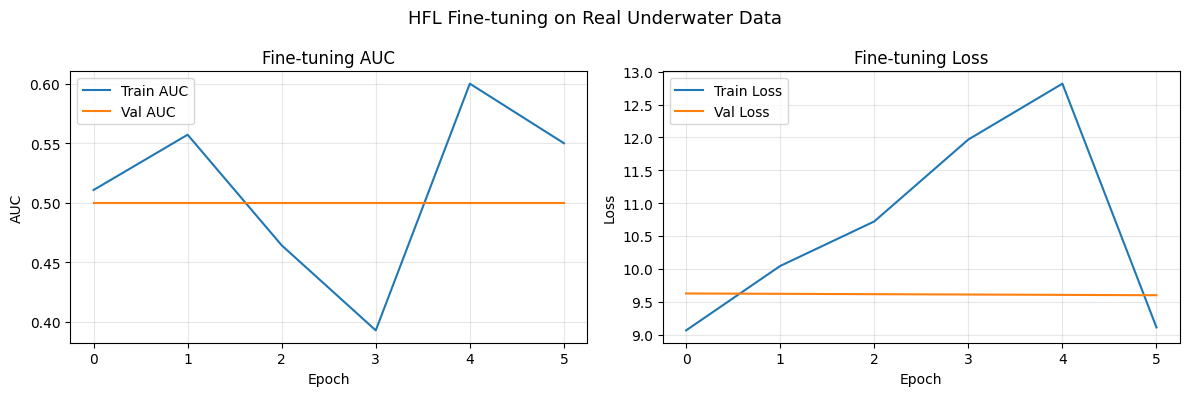


✅ Fine-tuned model saved
   hfl_finetuned_model.keras

STEP 6: Updating inference pipeline...
  Updated variables:
  hfl_model_finetuned ✅
  train_mean_real = [     32.139        35.6      30.036      31.812]
  train_std_real  = [     13.881      13.059      17.011      15.434]

  To use in CELL 8 replace:
  hfl_model → hfl_model_finetuned
  train_mean → train_mean_real
  train_std  → train_std_real

✅ Fine-tuning complete!
   Now re-run CELL 8 with:
   hfl_model = hfl_model_finetuned


In [7]:
# ══════════════════════════════════════════════════
# CELL 14 — Fine-tune HFL on real underwater data
# Fixes domain gap → fixes 100% risky problem
# ══════════════════════════════════════════════════

import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
from collections import deque
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════
# STEP 1 — Extract real angles from underwater videos
# ══════════════════════════════════════════════════

CONF_MIN       = 0.5
ANGLE_MIN      = 3.0
ANGLE_MAX      = 177.0
WATER_N        = 1.333
WINDOW         = 30
STEP           = 15
SMOOTH_WINDOW  = 5
MAX_ANGLE_JUMP = 30.0

def angle_2d(a, b, c):
    ba   = np.array([a[0]-b[0], a[1]-b[1]],
                    dtype=float)
    bc   = np.array([c[0]-b[0], c[1]-b[1]],
                    dtype=float)
    norm = np.linalg.norm(ba)*np.linalg.norm(bc)
    if norm < 1e-8:
        return 90.0
    return np.degrees(np.arccos(
        np.clip(np.dot(ba,bc)/norm,-1.0,1.0)))

def detect_water_surface(frame):
    gray  = cv2.cvtColor(frame,
                         cv2.COLOR_BGR2GRAY)
    sobel = cv2.Sobel(gray, cv2.CV_64F,
                      0, 1, ksize=5)
    norm  = np.uint8(
        255*np.absolute(sobel)/
        (np.absolute(sobel).max()+1e-8))
    top   = norm[:frame.shape[0]//2, :]
    return max(int(
        np.argmax(top.sum(axis=1))), 10)

def estimate_depth(y_pos, surface_y, h):
    if y_pos <= surface_y:
        return 0.0
    return min((y_pos-surface_y)/
               max(h-surface_y,1), 1.0)

def correct_refraction(angle, depth):
    if depth <= 0:
        return angle
    n = 1.0+(WATER_N-1.0)*depth
    s = np.clip(
        np.sin(np.radians(angle))/n,
        -1.0,1.0)
    return np.degrees(np.arcsin(s))

class AngleSmoother:
    def __init__(self, n=4, w=SMOOTH_WINDOW):
        self.bufs = [deque(maxlen=w)
                     for _ in range(n)]
    def update(self, angles):
        for i, a in enumerate(angles):
            self.bufs[i].append(a)
        return [np.mean(b) for b in self.bufs]

def remove_outliers(buffer, new_angles):
    if not buffer:
        return new_angles
    last    = buffer[-1]
    cleaned = []
    for new, prev in zip(new_angles, last):
        cleaned.append(
            prev if abs(new-prev)>MAX_ANGLE_JUMP
            else new)
    return cleaned

def smart_label_real(angles, stroke):
    """
    Auto-label real video angles
    using clinical thresholds from literature.
    Same smart_label logic as training data.
    """
    sh_lo = SAFE_RANGES[stroke]['shoulder'][0]
    sh_hi = SAFE_RANGES[stroke]['shoulder'][1]
    kn_lo = SAFE_RANGES[stroke]['knee'][0]
    kn_hi = SAFE_RANGES[stroke]['knee'][1]

    def label_with(a):
        sh = ((a[:,0]<sh_lo)|(a[:,0]>sh_hi)|
              (a[:,1]<sh_lo)|(a[:,1]>sh_hi))
        kn = ((a[:,2]<kn_lo)|(a[:,2]>kn_hi)|
              (a[:,3]<kn_lo)|(a[:,3]>kn_hi))
        return (sh|kn).astype(int)

    labels = label_with(angles)
    rate   = labels.mean()

    print(f"    Auto-label rate: {rate*100:.1f}%")

    # If too extreme use percentile fallback
    if rate < 0.05 or rate > 0.95:
        print(f"    Using percentile fallback...")
        for pct in range(5, 50, 5):
            slo = np.percentile(angles[:,0], pct)
            shi = np.percentile(angles[:,0],
                                100-pct)
            klo = np.percentile(angles[:,2], pct)
            khi = np.percentile(angles[:,2],
                                100-pct)
            lb  = ((angles[:,0]<slo)|
                   (angles[:,0]>shi)|
                   (angles[:,2]<klo)|
                   (angles[:,2]>khi)).astype(int)
            if 0.05 <= lb.mean() <= 0.95:
                print(f"    pct={pct} "
                      f"rate={lb.mean()*100:.1f}%")
                return lb

    return labels

# ── Extract angles from all underwater videos ─────
print("STEP 1: Extracting real angles...")
print("="*55)

real_data = {}

for video in underwater_videos:
    stroke = video.stem.split('_')[0]
    if stroke == 'backstroke':
        continue

    print(f"\n  Processing {video.name}...")

    cap       = cv2.VideoCapture(str(video))
    fps       = cap.get(cv2.CAP_PROP_FPS) or 30.0
    h_vid     = int(cap.get(
                    cv2.CAP_PROP_FRAME_HEIGHT))
    smoother  = AngleSmoother()
    buffer    = []
    all_angles= []
    frame_idx = 0
    collected = 0
    skipped   = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        results = yolo_pose(frame,
                            verbose=False)
        if not results or \
           len(results[0].keypoints) == 0:
            skipped += 1
            continue

        kps_data = results[0].keypoints
        if len(kps_data.xy) == 0:
            skipped += 1
            continue

        kps   = kps_data.xy[0].cpu().numpy()
        confs = kps_data.conf[0].cpu().numpy()

        required = [5,6,7,8,11,12,13,14,15,16]
        if any(confs[i] < CONF_MIN
               for i in required):
            skipped += 1
            continue

        def pt(idx):
            return (float(kps[idx][0]),
                    float(kps[idx][1]))

        ls_c  = float(confs[5])
        rs_c  = float(confs[6])
        tot   = ls_c + rs_c
        if tot < 1e-8:
            skipped += 1
            continue

        neck = (
            (pt(5)[0]*ls_c+pt(6)[0]*rs_c)/tot,
            (pt(5)[1]*ls_c+pt(6)[1]*rs_c)/tot,
        )

        r_sh = angle_2d(neck,   pt(6), pt(8))
        l_sh = angle_2d(neck,   pt(5), pt(7))
        r_kn = angle_2d(pt(12), pt(14), pt(16))
        l_kn = angle_2d(pt(11), pt(13), pt(15))

        # Refraction correction
        surface_y = detect_water_surface(frame)
        d_r_sh = estimate_depth(
            pt(6)[1], surface_y, h_vid)
        d_l_sh = estimate_depth(
            pt(5)[1], surface_y, h_vid)
        d_r_kn = estimate_depth(
            pt(14)[1], surface_y, h_vid)
        d_l_kn = estimate_depth(
            pt(13)[1], surface_y, h_vid)

        r_sh = correct_refraction(r_sh, d_r_sh)
        l_sh = correct_refraction(l_sh, d_l_sh)
        r_kn = correct_refraction(r_kn, d_r_kn)
        l_kn = correct_refraction(l_kn, d_l_kn)

        angles = [r_sh, l_sh, r_kn, l_kn]
        if not all(ANGLE_MIN <= a <= ANGLE_MAX
                   for a in angles):
            skipped += 1
            continue

        # Outlier removal + smoothing
        cleaned  = remove_outliers(
            buffer, angles)
        smoothed = smoother.update(cleaned)
        buffer.append(smoothed)
        if len(buffer) > WINDOW:
            buffer.pop(0)

        all_angles.append(smoothed)
        collected += 1

    cap.release()

    print(f"    Frames collected: {collected}")
    print(f"    Frames skipped:   {skipped}")

    if len(all_angles) >= WINDOW:
        real_data[stroke] = np.array(
            all_angles)
        print(f"    Angles shape: "
              f"{real_data[stroke].shape}")

print("\n✅ Step 1 complete")

# ══════════════════════════════════════════════════
# STEP 2 — Auto-label + create windows
# ══════════════════════════════════════════════════

print("\nSTEP 2: Auto-labeling real data...")
print("="*55)

real_client_data = {}

for stroke, angles in real_data.items():
    print(f"\n  {stroke.upper()}:")
    print(f"    Angle frames: {len(angles)}")

    # Auto-label using clinical thresholds
    labels = smart_label_real(angles, stroke)

    # Sliding window
    X, y = [], []
    for start in range(
            0, len(angles)-WINDOW+1, STEP):
        X.append(angles[start:start+WINDOW])
        y.append(int(
            labels[start:start+WINDOW]\
            .mean() > 0.5))

    X = np.array(X)
    y = np.array(y)

    print(f"    Windows:      {len(X)}")
    print(f"    Injury rate:  {y.mean()*100:.1f}%")

    if len(X) > 0:
        real_client_data[stroke] = {
            'X': X, 'y': y
        }

print("\n✅ Step 2 complete")

# ══════════════════════════════════════════════════
# STEP 3 — Compute real normalization stats
# ══════════════════════════════════════════════════

print("\nSTEP 3: Computing real stats...")
print("="*55)

all_real_angles = np.vstack([
    d['X'].reshape(-1,4)
    for d in real_client_data.values()])

real_mean = all_real_angles.mean(axis=0)
real_std  = all_real_angles.std(axis=0)

print(f"  Real mean: {real_mean}")
print(f"  Real std:  {real_std}")
print(f"\n  Synthetic mean: {train_mean}")
print(f"  Synthetic std:  {train_std}")
print(f"\n  Difference:")
names = ['R_sh','L_sh','R_kn','L_kn']
for i, name in enumerate(names):
    diff = real_mean[i] - train_mean[i]
    print(f"    {name}: {diff:+.1f}°")

# Save real stats
np.save(f'{BASE}/real_mean.npy', real_mean)
np.save(f'{BASE}/real_std.npy',  real_std)
print("\n✅ Real stats saved")

# ══════════════════════════════════════════════════
# STEP 4 — Fine-tune HFL model
# Freeze all layers except last 2
# Train on real underwater data
# ══════════════════════════════════════════════════

print("\nSTEP 4: Fine-tuning HFL model...")
print("="*55)

# Load base model
fine_tune_model = tf.keras.models.load_model(
    f'{BASE}/hfl_cloud_model.keras')

print("Original model layers:")
for i, layer in enumerate(
        fine_tune_model.layers):
    print(f"  {i:2d} {layer.name:<30} "
          f"trainable={layer.trainable}")

# Freeze all layers except last 2
for layer in fine_tune_model.layers[:-2]:
    layer.trainable = False

# Keep last 2 layers trainable
for layer in fine_tune_model.layers[-2:]:
    layer.trainable = True

print("\nAfter freezing:")
trainable = sum(
    1 for l in fine_tune_model.layers
    if l.trainable)
frozen    = sum(
    1 for l in fine_tune_model.layers
    if not l.trainable)
print(f"  Trainable layers: {trainable}")
print(f"  Frozen layers:    {frozen}")

# Recompile with lower learning rate
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        0.0001),  # lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
    ])

# Prepare real training data
# Normalize using REAL stats
def normalize_real(window):
    return (window - real_mean) / \
           (real_std + 1e-8)

X_real_all = []
y_real_all = []

for stroke, data in real_client_data.items():
    X_norm = np.array([
        normalize_real(w)
        for w in data['X']])
    X_real_all.append(X_norm)
    y_real_all.append(data['y'])

X_real = np.concatenate(X_real_all)
y_real = np.concatenate(y_real_all)

print(f"\n  Real training data:")
print(f"  Shape: {X_real.shape}")
print(f"  Injury rate: {y_real.mean()*100:.1f}%")

# Train/val split
X_tr, X_val, y_tr, y_val = \
    train_test_split(
        X_real, y_real,
        test_size=0.2,
        random_state=42,
        stratify=y_real
        if y_real.sum() > 0
        else None)

print(f"\n  Train: {len(X_tr)}")
print(f"  Val:   {len(X_val)}")

# Fine-tune
print("\n  Training...")
history = fine_tune_model.fit(
    X_tr.astype(np.float32),
    y_tr.astype(np.float32),
    validation_data=(
        X_val.astype(np.float32),
        y_val.astype(np.float32)),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=5,
            restore_best_weights=True,
            mode='max'),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1)
    ])

# ══════════════════════════════════════════════════
# STEP 5 — Evaluate fine-tuned model
# ══════════════════════════════════════════════════

print("\nSTEP 5: Evaluating fine-tuned model...")
print("="*55)

# Evaluate on real data
probs = fine_tune_model.predict(
    X_val.astype(np.float32),
    verbose=0).flatten()
preds = (probs >= 0.35).astype(int)

auc = roc_auc_score(y_val, probs) \
      if len(np.unique(y_val)) > 1 \
      else 0.0
f1  = f1_score(y_val, preds,
               zero_division=0)
acc = (preds == y_val).mean()

print(f"\n  Fine-tuned model on real data:")
print(f"  AUC : {auc:.4f}")
print(f"  F1  : {f1:.4f}")
print(f"  Acc : {acc*100:.1f}%")

# Plot training history
fig, axes = plt.subplots(1,2,
                          figsize=(12,4))
axes[0].plot(history.history['auc'],
             label='Train AUC')
axes[0].plot(history.history['val_auc'],
             label='Val AUC')
axes[0].set_title('Fine-tuning AUC')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],
             label='Train Loss')
axes[1].plot(history.history['val_loss'],
             label='Val Loss')
axes[1].set_title('Fine-tuning Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'HFL Fine-tuning on Real Underwater Data',
    fontsize=13)
plt.tight_layout()
plt.savefig(
    f'{BASE}/finetune_history.png',
    dpi=150, bbox_inches='tight')
plt.show()

# Save fine-tuned model
fine_tune_model.save(
    f'{BASE}/hfl_finetuned_model.keras')
print(f"\n✅ Fine-tuned model saved")
print(f"   hfl_finetuned_model.keras")

# ══════════════════════════════════════════════════
# STEP 6 — Save real normalization stats
# and update inference to use fine-tuned model
# ══════════════════════════════════════════════════

print("\nSTEP 6: Updating inference pipeline...")
print("="*55)

# Update global variables for CELL 8
hfl_model_finetuned = fine_tune_model
train_mean_real     = real_mean
train_std_real      = real_std

print("  Updated variables:")
print(f"  hfl_model_finetuned ✅")
print(f"  train_mean_real = {real_mean}")
print(f"  train_std_real  = {real_std}")
print()
print("  To use in CELL 8 replace:")
print("  hfl_model → hfl_model_finetuned")
print("  train_mean → train_mean_real")
print("  train_std  → train_std_real")
print()
print("✅ Fine-tuning complete!")
print("   Now re-run CELL 8 with:")
print("   hfl_model = hfl_model_finetuned")